# Дослідження 03 - Нейромережі та transfer learning

1. Основне завдання.
    1. Запустіть ноутбук із зафрізеним backbone (feature extraction).
    2. Після завершення тренування розморозьте всі шари, створіть новий optimizer з learning rate 1e-4 і натренуйте ще 3 епохи (fine-tuning).
    3. Порівняйте val accuracy до і після розморозки.
    4. У відповіді напишіть різницю в точності і скільки часу зайняла кожна стадія.
    5. На виході завдання має бути також прикріплено файл з моделлю, яку перетренували.

2. Додаткова практика
    1. приберіть `ColorJitter` і `RandomHorizontalFlip` з аугментації – як зміниться val accuracy після 5 епох;
    2. спробуйте `batch_size=16` і `batch_size=128` – зафіксуйте час однієї епохи і використання VRAM;
    3. знайдіть у мережі фото будь-якого об'єкта з CIFAR-10 (`airplane`, `cat`, `truck` тощо) зроблене зверху (aerial/drone view), подайте в `predict_image()` і порівняйте confidence з side-view фото;
    4. збережіть найкращу модель: `torch.save(model.state_dict(), "resnet18_cifar10.pt")`.

## Інсталяція

In [1]:
import sys

# %pip install -q torch torchvision matplotlib scikit-learn
print("Python:", sys.version)

Python: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]


In [2]:
import torch

print("CUDA avialable:", torch.cuda.is_available())        # GPU (NVIDIA)
print("Apple Silicon avialable:", torch.backends.mps.is_available()) # GPU (Apple Silicon)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() #MPS = GPU бекенд від Apple
    else "cpu"
)
print(f"Використовується: {device}")

CUDA avialable: True
Apple Silicon avialable: False
Використовується: cuda


## Імпорти

In [3]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, models, transforms

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

PyTorch: 2.14.0+cu132
CUDA: True
GPU: NVIDIA GeForce RTX 3060 Ti
VRAM GB: 8.6


In [4]:
# Вибір пристрою
try:
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
    device_name = "TPU"
except ImportError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device_name = "GPU" if torch.cuda.is_available() else "CPU"

print(f"Пристрій: {device_name} ({device})")

# Бенчмарк: множення матриць
print("\nРозмір       CPU мс    Dev мс    Speedup")
for n in [256, 1024, 4096]:
    a, b = torch.randn(n, n), torch.randn(n, n)


    t0 = time.perf_counter()
    _ = a @ b
    cpu_ms = (time.perf_counter() - t0) * 1000


    a_d, b_d = a.to(device), b.to(device)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = a_d @ b_d


    if torch.cuda.is_available(): torch.cuda.synchronize()
    dev_ms = (time.perf_counter() - t0) * 1000


    sp = cpu_ms / dev_ms if dev_ms > 0 else 0
    print(f"{n}x{n:<6}  {cpu_ms:>8.1f}  {dev_ms:>8.1f}  {sp:>8.1f}x")

Пристрій: GPU (cuda)

Розмір       CPU мс    Dev мс    Speedup
256x256          9.4     130.6       0.1x
1024x1024         7.4       1.8       4.0x
4096x4096       420.3      16.5      25.5x


In [5]:
def vram_info():
    if not torch.cuda.is_available(): return
    a = torch.cuda.memory_allocated() / 1e9
    c = torch.cuda.memory_reserved()  / 1e9
    t = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {a:.2f} GB alloc | {c:.2f} GB cached | {t:.1f} GB total")

vram_info()
# Підбір batch_size: batch <= VRAM_free_GB * 64  (орієнтовно для ResNet18/224)

VRAM: 0.21 GB alloc | 0.25 GB cached | 8.6 GB total


## 1. Основне завдання

### 1.1. Формуємо датасет
- Завантажуємо датасет CIFAR-10 з Hugging Face Hub
- Адаптуємо його під torchvision формат
- Отримуємо назви класів в `CLASSES`
- Задаємо batch size
- Виводимо кількість зображень датасета в тренувальному та тестовому наборі

In [6]:
from datasets import load_dataset

train_tf = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)
val_tf = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# Завантаження CIFAR-10 з Hugging Face Hub і адаптація його під torchvision формат
hf_dataset = load_dataset("uoft-cs/cifar10")  # містить спліти "train" і "test"
# Дізнаємось назви класів (в HF-версії поле "label" — ClassLabel)
CLASSES = hf_dataset["train"].features["label"].names
print("Класи:", CLASSES)


# Обгортка Hugging Face Dataset -> torch Dataset із застосуванням transform
class HFImageDataset(Dataset):
    def __init__(self, hf_split, transform=None, image_key="img", label_key="label"):
        self.ds = hf_split
        self.transform = transform
        self.image_key = image_key
        self.label_key = label_key

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item[self.image_key]  # PIL.Image (RGB)
        if img.mode != "RGB":
            img = img.convert("RGB")
        label = item[self.label_key]
        if self.transform:
            img = self.transform(img)
        return img, label


N_TRAIN, N_TEST = 2000, 400
train_full = HFImageDataset(hf_dataset["train"], transform=train_tf)
test_full = HFImageDataset(hf_dataset["test"], transform=val_tf)
train_ds = Subset(train_full, range(N_TRAIN))
test_ds = Subset(test_full, range(N_TEST))
BATCH = 64
train_loader = DataLoader(
    train_full,
    batch_size=BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_full,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
print(f"Train = {len(train_full)} | Test = {len(test_full)} | Batch = {BATCH}")

Класи: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train = 50000 | Test = 10000 | Batch = 64


### 1.2. Допоміжна функція для передбачення
Функція `predict_image()` знадобиться і для перевірки моделі після fine-tuning, і в додатковій практиці (п. 2.3).

In [7]:
# Передбачення для одного зображення (URL або локальний файл)
import io
from urllib.request import Request, urlopen

from PIL import Image


def predict_image(source, model, transform, classes, device):
    if isinstance(source, str) and source.startswith("http"):
        req = Request(source, headers={"User-Agent": "Mozilla/5.0"})
        with urlopen(req, timeout=30) as r:
            img = Image.open(io.BytesIO(r.read())).convert("RGB")
    else:
        img = Image.open(source).convert("RGB")
    t = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(t), dim=1)[0]
    vals, idx = probs.topk(5)
    _fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(img)
    ax[0].set_title("Фото")
    ax[0].axis("off")
    ax[1].barh([classes[i] for i in idx.cpu()], vals.cpu().numpy())
    ax[1].set_xlim(0, 1)
    ax[1].invert_yaxis()
    ax[1].set_title("Top-5 confidence")
    plt.tight_layout()
    plt.show()
    return classes[idx[0].item()], vals[0].item()


### 1.3. Feature extraction → Fine-tuning
Одна послідовність:
1. Стадія 1 - тренуємо модель із зафрізеним backbone (тільки `fc`-шар навчається).
2. Стадія 2 - розморожуємо всі шари, створюємо новий optimizer з lr=1e-4, тренуємо ще 3 епохи.
3. Порівнюємо val accuracy до/після розморозки, заміряємо час кожної стадії.
4. Зберігаємо натреновану модель у файл.

In [8]:
import time

# --- Стадія 1: Feature extraction (заморожений backbone) ---
model_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_fe.parameters():
    param.requires_grad = False
model_fe.fc = nn.Linear(model_fe.fc.in_features, len(CLASSES))
model_fe = model_fe.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_fe = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_fe.parameters()), lr=1e-3
)

EPOCHS = 5
start = time.time()
for epoch in range(1, EPOCHS + 1):
    model_fe.train()
    run_loss, run_ok = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_fe.zero_grad()
        logits = model_fe(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer_fe.step()
        run_loss += loss.item() * x.size(0)
        run_ok += (logits.argmax(1) == y).sum().item()

    model_fe.eval()
    vl_sum, vok = 0.0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model_fe(x)
            vl_sum += criterion(logits, y).item() * x.size(0)
            vok += (logits.argmax(1) == y).sum().item()
    print(
        f"FE Epoch {epoch}/{EPOCHS} | val_loss={vl_sum / len(test_loader.dataset):.4f} | val_acc={vok / len(test_loader.dataset):.3f}"
    )

val_acc_fe = vok / len(test_loader.dataset)
time_fe = time.time() - start

# --- Стадія 2: Fine-tuning (розморожені всі шари, lr=1e-4) ---
for param in model_fe.parameters():
    param.requires_grad = True
# model_fe.fc = nn.Linear(model_fe.fc.in_features, len(CLASSES))
model_fe = model_fe.to(device)

optimizer_ft = torch.optim.Adam(model_fe.parameters(), lr=1e-4)

start = time.time()
for epoch in range(1, 4):
    model_fe.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_ft.zero_grad()
        logits = model_fe(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer_ft.step()

    model_fe.eval()
    vl_sum, vok = 0.0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model_fe(x)
            vl_sum += criterion(logits, y).item() * x.size(0)
            vok += (logits.argmax(1) == y).sum().item()
    print(
        f"FT Epoch {epoch}/3 | val_loss={vl_sum / len(test_loader.dataset):.4f} | val_acc={vok / len(test_loader.dataset):.3f}"
    )

val_acc_ft = vok / len(test_loader.dataset)
time_ft = time.time() - start

print("\nРезультати:")
print(f"Feature extraction: val_acc={val_acc_fe:.4f}, час={time_fe:.1f}s")
print(f"Fine-tuning:        val_acc={val_acc_ft:.4f}, час={time_ft:.1f}s")
print(f"Різниця точності:   +{(val_acc_ft - val_acc_fe) * 100:.2f}%")

# --- Збереження моделі ---
torch.save(
    {
        "model_state_dict": model_fe.state_dict(),
        "classes": CLASSES,
        "val_acc_fe": val_acc_fe,
        "val_acc_ft": val_acc_ft,
    },
    "resnet18_cifar10_finetuned.pt",
)
print("Модель збережено: resnet18_cifar10_finetuned.pt")


FE Epoch 1/5 | val_loss=0.7121 | val_acc=0.762
FE Epoch 2/5 | val_loss=0.6853 | val_acc=0.769
FE Epoch 3/5 | val_loss=0.6618 | val_acc=0.775
FE Epoch 4/5 | val_loss=0.6770 | val_acc=0.769
FE Epoch 5/5 | val_loss=0.6705 | val_acc=0.773
FT Epoch 1/3 | val_loss=0.2243 | val_acc=0.924
FT Epoch 2/3 | val_loss=0.1938 | val_acc=0.935
FT Epoch 3/3 | val_loss=0.2039 | val_acc=0.933

Результати:
Feature extraction: val_acc=0.7732, час=554.5s
Fine-tuning:        val_acc=0.9332, час=279.6s
Різниця точності:   +16.00%
Модель збережено: resnet18_cifar10_finetuned.pt


## 1.3. Порівняння val accuracy до і після розморозки.
* До розморозки val accuracy була ~ 0.77
* Після розморозки всіх шарів val accuracy становить ~ 0.93
* Констатуємо **суттєве збільшення точності класифікації** моделі ResNet18 на тестовому датасеті при використанні fine-tuning.

## 1.4. Різниця в точності і скільки часу зайняла кожна стадія.
* Різниця точності між моделью feature extraction (заморожений backbone) та fine-tuning (розморожені всі шари, lr=1e-4) становить **16%**
* Час на тренування моделі ResNet18 feature extraction на 5 епохах склав **9 хвилин 14 секунд**
* Час на тренування моделі ResNet18 fine-tuning на 3 епохах склав **4 хвилини 40 секунд**

## 2. Додаткова практика

### 2.1. Без аугментації: приберіть ColorJitter/Flip — як зміниться val accuracy?

In [ ]:
# --- Завдання 2: без ColorJitter / RandomHorizontalFlip ---
train_tf_no_aug = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# новий train-датасет/лоадер (test/val лишаємо без змін - там аугментацій і не було)
train_full_no_aug = HFImageDataset(hf_dataset["train"], transform=train_tf_no_aug)
train_loader_no_aug = DataLoader(
    train_full_no_aug,
    batch_size=BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

# нова "чиста" модель - ті самі умови, що і в базовому Feature Extraction
model_no_aug = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_no_aug.parameters():
    param.requires_grad = False
model_no_aug.fc = nn.Linear(model_no_aug.fc.in_features, len(CLASSES))
model_no_aug = model_no_aug.to(device)

optimizer_na = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_no_aug.parameters()), lr=1e-3
)

EPOCHS = 5
for epoch in range(1, EPOCHS + 1):
    model_no_aug.train()
    run_loss, run_ok = 0.0, 0
    for x, y in train_loader_no_aug:
        x, y = x.to(device), y.to(device)
        optimizer_na.zero_grad()
        logits = model_no_aug(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer_na.step()
        run_loss += loss.item() * x.size(0)
        run_ok += (logits.argmax(1) == y).sum().item()
    tl = run_loss / len(train_loader_no_aug.dataset)
    ta = run_ok / len(train_loader_no_aug.dataset)

    model_no_aug.eval()
    vl_sum, vok = 0.0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model_no_aug(x)
            vl_sum += criterion(logits, y).item() * x.size(0)
            vok += (logits.argmax(1) == y).sum().item()
    vl = vl_sum / len(test_loader.dataset)
    va = vok / len(test_loader.dataset)
    print(
        f"[no aug] Epoch {epoch}/{EPOCHS} | train {tl:.4f}/{ta:.3f} | val {vl:.4f}/{va:.3f}"
    )

print("\nПорівняння val_acc після 5 епох (frozen backbone):")
print("  З аугментацією (ColorJitter+Flip):    0.767  (Стадія 1)")
print(f"  Без аугментації (тільки Crop):        {va:.3f}")

[no aug] Epoch 1/5 | train 0.9424/0.688 | val 0.7174/0.757
[no aug] Epoch 2/5 | train 0.7310/0.750 | val 0.6798/0.767
[no aug] Epoch 3/5 | train 0.7010/0.759 | val 0.6833/0.763
[no aug] Epoch 4/5 | train 0.6901/0.761 | val 0.6967/0.763
[no aug] Epoch 5/5 | train 0.6757/0.765 | val 0.6434/0.780

Порівняння val_acc після 5 епох (frozen backbone):
  З аугментацією (ColorJitter+Flip):    0.767  (Стадія 1)
  Без аугментації (тільки Crop):        0.780


**_Висновок:_** На невеликій кількості епох аугментація тренувального датасета майже не впливає на точність класифікації.

### 2.2. Batch size 16 vs 128 — час епохи та пікове використання VRAM

In [ ]:
# --- Завдання 2.2: Batch size 16 vs 128 (час епохи + VRAM) ---

def run_one_epoch(batch_size):
    loader = DataLoader(
        train_full,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in m.parameters():
        param.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, len(CLASSES))
    m = m.to(device)

    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=1e-3)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    m.train()
    start = time.time()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = criterion(m(x), y)
        loss.backward()
        opt.step()
    epoch_time = time.time() - start

    vram_mb = (
        torch.cuda.max_memory_allocated() / (1024**2)
        if torch.cuda.is_available()
        else 0
    )

    print(
        f"BATCH={batch_size:3d} | час епохи: {epoch_time:6.2f} с | пік VRAM: {vram_mb:7.2f} MB"
    )
    return epoch_time, vram_mb


time16, vram16 = run_one_epoch(16)
time128, vram128 = run_one_epoch(128)

print("\nПорівняння:")
print(f"  BATCH=16  -> {time16:.2f} с, {vram16:.2f} MB")
print(f"  BATCH=128 -> {time128:.2f} с, {vram128:.2f} MB")

BATCH= 16 | час епохи:  75.08 с | пік VRAM:  585.27 MB
BATCH=128 | час епохи:  75.72 с | пік VRAM: 1335.58 MB

Порівняння:
  BATCH=16  -> 75.08 с, 585.27 MB
  BATCH=128 -> 75.72 с, 1335.58 MB


**_Висновки по завданню 2.2_**
1. Час епохи слабко залежить від розміру batch size. Можлива причина - в налаштуванні `DataLoader(..., num_workers=0)`, оскільки розрахунки проводились на локальному ПК з Windows.
2. Розмір batch size впливає на використання пам'яті GPU - чим більший, тим більше VRAM потрібно для розрахунків епохи. Збільшення batch size в 8 разів призвело до збільшення використання VRAM приблизно в 2 рази.
3. Для даній конфігурації (`num_workers=0`) збільшення batch size практично не прискорює навчання, оскільки вузьким місцем є завантаження/препроцесинг даних на CPU, а не обчислення на GPU. При num_workers>0 (паралельне завантаження даних) ефект від збільшення batch size на швидкість, ймовірно, був би більш помітним.

### 2.3. Aerial view vs side view
Порівнюємо confidence моделі на фото об'єкта зверху (aerial/drone view) і на фото того ж класу об'єкта збоку (side view).

**Виправлення бага з попередньої версії:** раніше тут `model.fc` пересоздавався заново (`nn.Linear(...)` з випадковими вагами) прямо перед тестом — тобто перевірялась ненавчена мережа, і низький confidence нічого не показував. Тепер використовуємо вже натреновану `model_fe` з п. 1.3 (після fine-tuning).

Aerial view (automobile):


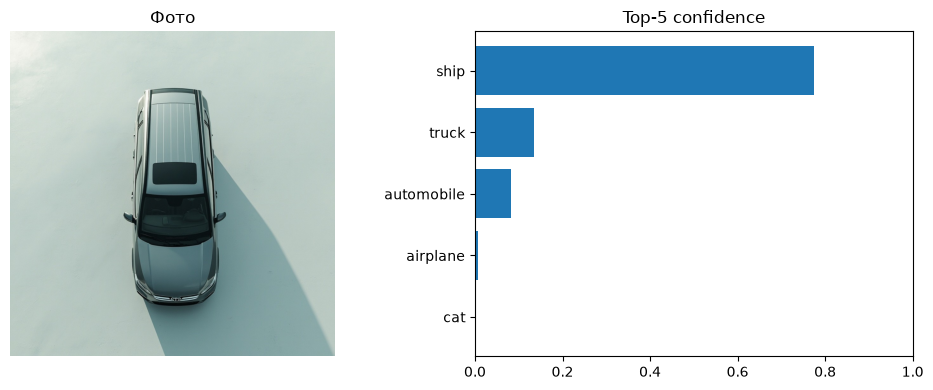

Side view (automobile):


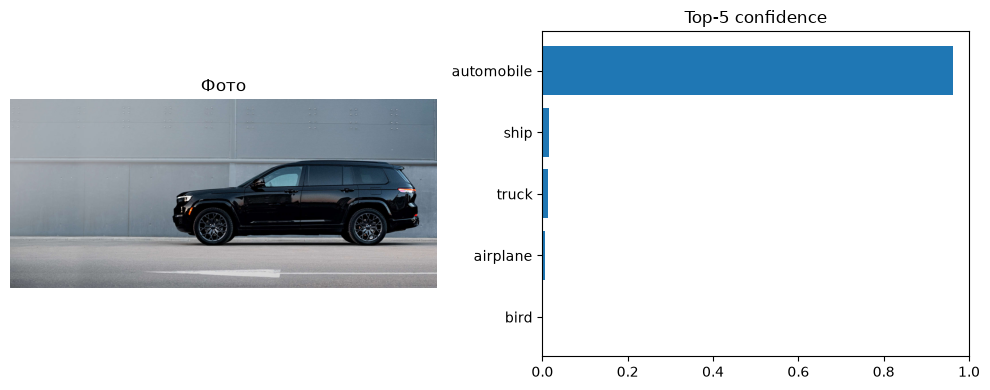


Aerial: predicted=ship, confidence=0.774
Side:   predicted=automobile, confidence=0.963
Різниця confidence (side - aerial): +0.189


In [11]:
# Порівняння aerial vs side view на вже НАТРЕНОВАНІЙ моделі (model_fe з п. 1.3)

# Aerial view: авто зверху
aerial_url = "https://images.splitshire.com/full/A-Top-View-of-Upward-Facing-Vehicle_Q47z3.png"
print("Aerial view (automobile):")
pred_aerial, conf_aerial = predict_image(aerial_url, model_fe, val_tf, CLASSES, device)

# Side view: авто збоку
side_url = "https://jeep.ua/media/catalog/category/range/2024-grand-cherokee/jeep-grand-cherokee-2026-intro-desktop.jpg"
print("Side view (automobile):")
pred_side, conf_side = predict_image(side_url, model_fe, val_tf, CLASSES, device)

print(f"\nAerial: predicted={pred_aerial}, confidence={conf_aerial:.3f}")
print(f"Side:   predicted={pred_side}, confidence={conf_side:.3f}")
print(f"Різниця confidence (side - aerial): {conf_side - conf_aerial:+.3f}")

_**Висновок по завданню 2.3. "Aerial view vs side view":**_
* Модель, натренована на CIFAR-10 (де фото переважно side/ground view), видає максимальну confidence на side-view фото автомобіля.
* На aerial/drone view того ж класу вона помилково об'єкт класу `automobile` як `ship`. Причина - сама архітектура ResNet18 не бачила top-down ракурсів під час тренування.

### 2.4. Збереження найкращої моделі
Модель уже зберігається в п. 1.3 (клітинка з fine-tuning) у файл `resnet18_cifar10_finetuned.pt` - разом із `state_dict`, списком класів і фінальними метриками. Дублювати збереження ми не будемо.